# 01 — Dataset audit and target engineering

**Business question:** Can we predict movie commercial success *before* release?

This notebook:
- Loads TMDB 5000 **movies** and **credits** (if present under `data/raw/`).
- Audits structure, quality, and key columns.
- Builds **ROI** and the **3-class target** `movie_success_class` (labels only — revenue/budget used for the target, not as model features later).
- Adds simple **calendar** and **parsed JSON** derived fields for the next modeling phase.
- Writes a cleaned table to `data/processed/movies_cleaned_with_target.csv`.

> Run cells from top to bottom. If CSVs are missing, paths are still defined and early checks explain what to download.


## Setup

Paths resolve from the notebook working directory (repo root or `notebooks/`).


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import numpy as np
import pandas as pd

# Resolve project root whether Jupyter cwd is repo root or notebooks/
_CWD = Path.cwd().resolve()
if (_CWD / "data" / "raw").is_dir():
    PROJECT_ROOT = _CWD
elif (_CWD.parent / "data" / "raw").is_dir():
    PROJECT_ROOT = _CWD.parent
else:
    PROJECT_ROOT = _CWD
    print("Warning: could not find data/raw next to cwd or parent; using cwd as PROJECT_ROOT.")

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

MOVIES_PATH = RAW_DIR / "tmdb_5000_movies.csv"
CREDITS_PATH = RAW_DIR / "tmdb_5000_credits.csv"
OUTPUT_PATH = PROCESSED_DIR / "movies_cleaned_with_target.csv"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("MOVIES_PATH exists:", MOVIES_PATH.exists())
print("CREDITS_PATH exists:", CREDITS_PATH.exists())


PROJECT_ROOT: /Users/paulbensemoun/Documents/ml_poc/new-project
MOVIES_PATH exists: True
CREDITS_PATH exists: True


## 1. Load CSVs

If files are absent, the next cell still defines paths above; load steps are skipped with a clear message.


In [2]:
movies = None
credits = None

if MOVIES_PATH.exists():
    movies = pd.read_csv(MOVIES_PATH)
    print(f"Loaded movies: {movies.shape}")
else:
    print(f"Missing: {MOVIES_PATH}")
    print("Download TMDB 5000 Movie Dataset and place tmdb_5000_movies.csv in data/raw/.")

if CREDITS_PATH.exists():
    credits = pd.read_csv(CREDITS_PATH)
    print(f"Loaded credits: {credits.shape}")
else:
    print(f"Missing: {CREDITS_PATH}")
    print("Optional: add tmdb_5000_credits.csv alongside movies for cast/crew exploration later.")


Loaded movies: (4803, 20)
Loaded credits: (4803, 4)


## 2. Overview — shape, columns, dtypes, missing values, duplicates


In [3]:
if movies is None:
    print("Skip: movies not loaded.")
else:
    display(movies.head(3))
    print("shape:", movies.shape)
    print("columns:", list(movies.columns))
    display(movies.dtypes.to_frame("dtype"))
    missing = movies.isna().sum().sort_values(ascending=False)
    display(missing[missing > 0].to_frame("missing_count"))
    dup_id = movies["id"].duplicated().sum() if "id" in movies.columns else None
    print("Duplicate id count:", dup_id)
    print("Full-row duplicate count:", int(movies.duplicated().sum()))


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466


shape: (4803, 20)
columns: ['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count']


,dtype
budget,int64
genres,object
homepage,object
id,int64
keywords,object
original_language,object
original_title,object
overview,object
popularity,float64
production_companies,object


,missing_count
homepage,3091
tagline,844
overview,3
runtime,2
release_date,1


Duplicate id count: 0
Full-row duplicate count: 0


In [4]:
if credits is None:
    print("Skip: credits not loaded.")
else:
    display(credits.head(3))
    print("shape:", credits.shape)
    print("columns:", list(credits.columns))
    display(credits.dtypes.to_frame("dtype"))
    missing_c = credits.isna().sum().sort_values(ascending=False)
    display(missing_c[missing_c > 0].to_frame("missing_count"))
    if "movie_id" in credits.columns:
        print("Duplicate movie_id count:", int(credits["movie_id"].duplicated().sum()))
    print("Full-row duplicate count:", int(credits.duplicated().sum()))


,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."


shape: (4803, 4)
columns: ['movie_id', 'title', 'cast', 'crew']


,dtype
movie_id,int64
title,object
cast,object
crew,object


,missing_count


Duplicate movie_id count: 0
Full-row duplicate count: 0


## 3. Inspect important movie columns

Focus on fields relevant to **pre-release** modeling and to **target** construction (revenue, budget).


In [5]:
cols = [
    "budget",
    "revenue",
    "genres",
    "runtime",
    "release_date",
    "original_language",
    "production_companies",
    "production_countries",
    "spoken_languages",
    "vote_average",
    "vote_count",
    "popularity",
]
if movies is None:
    print("Skip: movies not loaded.")
else:
    present = [c for c in cols if c in movies.columns]
    missing_cols = [c for c in cols if c not in movies.columns]
    if missing_cols:
        print("Columns not in dataset:", missing_cols)
    display(movies[present].head(10))
    for c in present:
        print(c, "| nulls:", movies[c].isna().sum(), "| nunique:", movies[c].nunique(dropna=True))


,budget,revenue,genres,runtime,release_date,original_language,production_companies,production_countries,spoken_languages,vote_average,vote_count,popularity
0,237000000,2787965087,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",162.0,2009-12-10,en,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...","[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",7.2,11800,150.437577
1,300000000,961000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",169.0,2007-05-19,en,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...","[{""iso_639_1"": ""en"", ""name"": ""English""}]",6.9,4500,139.082615
2,245000000,880674609,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",148.0,2015-10-26,en,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...","[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",6.3,4466,107.376788
3,250000000,1084939099,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",165.0,2012-07-16,en,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...","[{""iso_639_1"": ""en"", ""name"": ""English""}]",7.6,9106,112.312950
4,260000000,284139100,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",132.0,2012-03-07,en,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...","[{""iso_639_1"": ""en"", ""name"": ""English""}]",6.1,2124,43.926995
5,258000000,890871626,"[{""id"": 14, ""name"": ""Fantasy""}, {""id"": 28, ""na...",139.0,2007-05-01,en,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...","[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",5.9,3576,115.699814
6,260000000,591794936,"[{""id"": 16, ""name"": ""Animation""}, {""id"": 10751...",100.0,2010-11-24,en,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...","[{""iso_639_1"": ""en"", ""name"": ""English""}]",7.4,3330,48.681969
7,280000000,1405403694,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",141.0,2015-04-22,en,"[{""name"": ""Marvel Studios"", ""id"": 420}, {""name...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...","[{""iso_639_1"": ""en"", ""name"": ""English""}]",7.3,6767,134.279229
8,250000000,933959197,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",153.0,2009-07-07,en,"[{""name"": ""Warner Bros."", ""id"": 6194}, {""name""...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...","[{""iso_639_1"": ""en"", ""name"": ""English""}]",7.4,5293,98.885637
9,250000000,873260194,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",151.0,2016-03-23,en,"[{""name"": ""DC Comics"", ""id"": 429}, {""name"": ""A...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...","[{""iso_639_1"": ""en"", ""name"": ""English""}]",5.7,7004,155.790452


budget | nulls: 0 | nunique: 436
revenue | nulls: 0 | nunique: 3297
genres | nulls: 0 | nunique: 1175
runtime | nulls: 2 | nunique: 156
release_date | nulls: 1 | nunique: 3280
original_language | nulls: 0 | nunique: 37
production_companies | nulls: 0 | nunique: 3697
production_countries | nulls: 0 | nunique: 469
spoken_languages | nulls: 0 | nunique: 544
vote_average | nulls: 0 | nunique: 71
vote_count | nulls: 0 | nunique: 1609
popularity | nulls: 0 | nunique: 4802


## 4. Parse JSON-like string columns

TMDB encodes nested lists as JSON strings. We parse safely and keep raw strings available until save.


In [6]:
JSON_LIST_COLS = ["genres", "production_companies", "production_countries", "spoken_languages"]


def parse_json_list(value):
    """Return a list of dicts from a TMDB JSON array column; empty list if invalid/NaN."""
    if pd.isna(value):
        return []
    if isinstance(value, list):
        return value
    if isinstance(value, str):
        s = value.strip()
        if not s:
            return []
        try:
            out = json.loads(s)
            return out if isinstance(out, list) else []
        except json.JSONDecodeError:
            return []
    return []


if movies is None:
    print("Skip: movies not loaded.")
else:
    for col in JSON_LIST_COLS:
        if col not in movies.columns:
            print(f"Skip parse: missing column {col}")
            continue
        parsed_col = f"{col}_parsed"
        movies[parsed_col] = movies[col].map(parse_json_list)
        bad = movies[col].notna() & (movies[parsed_col].map(len) == 0)
        print(col, "rows with non-null raw but empty parse:", int(bad.sum()))


genres rows with non-null raw but empty parse: 28
production_companies rows with non-null raw but empty parse: 351
production_countries rows with non-null raw but empty parse: 174
spoken_languages rows with non-null raw but empty parse: 86


## 5. Rows unusable for ROI / target

Drop rows where **budget** or **revenue** is missing or non-positive (ROI undefined or not meaningful for this PoC).


In [7]:
if movies is None:
    print("Skip: movies not loaded.")
else:
    m = movies.copy()
    n_start = len(m)
    if "budget" not in m.columns or "revenue" not in m.columns:
        raise ValueError("Expected columns 'budget' and 'revenue' for target creation.")

    m["budget"] = pd.to_numeric(m["budget"], errors="coerce")
    m["revenue"] = pd.to_numeric(m["revenue"], errors="coerce")

    invalid_budget = m["budget"].isna() | (m["budget"] <= 0)
    invalid_revenue = m["revenue"].isna() | (m["revenue"] <= 0)
    print("Rows with missing or non-positive budget:", int(invalid_budget.sum()))
    print("Rows with missing or non-positive revenue:", int(invalid_revenue.sum()))

    m = m.loc[~invalid_budget & ~invalid_revenue].copy()
    print(f"Rows kept: {len(m)} / {n_start}")
    movies_valid = m


Rows with missing or non-positive budget: 1037
Rows with missing or non-positive revenue: 1427
Rows kept: 3229 / 4803


## 6. ROI and 7. Target `movie_success_class`

- **flop:** ROI < 1
- **average:** 1 ≤ ROI < 2
- **hit:** ROI ≥ 2


In [8]:
if movies is None:
    print("Skip: movies not loaded.")
else:
    movies_valid["roi"] = movies_valid["revenue"] / movies_valid["budget"]

    def movie_success_class(roi: float) -> str:
        if roi < 1:
            return "flop"
        if roi < 2:
            return "average"
        return "hit"

    movies_valid["movie_success_class"] = movies_valid["roi"].map(movie_success_class)
    order = pd.CategoricalDtype(["flop", "average", "hit"], ordered=True)
    movies_valid["movie_success_class"] = movies_valid["movie_success_class"].astype(order)

    display(movies_valid[["budget", "revenue", "roi", "movie_success_class"]].describe(include="all"))


,budget,revenue,roi,movie_success_class
count,3.229000e+03,3.229000e+03,3.229000e+03,3229
unique,NaN,NaN,NaN,3
top,NaN,NaN,NaN,hit
freq,NaN,NaN,NaN,1809
mean,4.065444e+07,1.212430e+08,2.954822e+03,NaN
std,4.439674e+07,1.863029e+08,1.506101e+05,NaN
min,1.000000e+00,5.000000e+00,5.217391e-07,NaN
25%,1.050000e+07,1.700000e+07,1.022463e+00,NaN
50%,2.500000e+07,5.518472e+07,2.300366e+00,NaN
75%,5.500000e+07,1.462920e+08,4.420822e+00,NaN


## 8. Target distribution


,count
movie_success_class,
flop,789
average,631
hit,1809


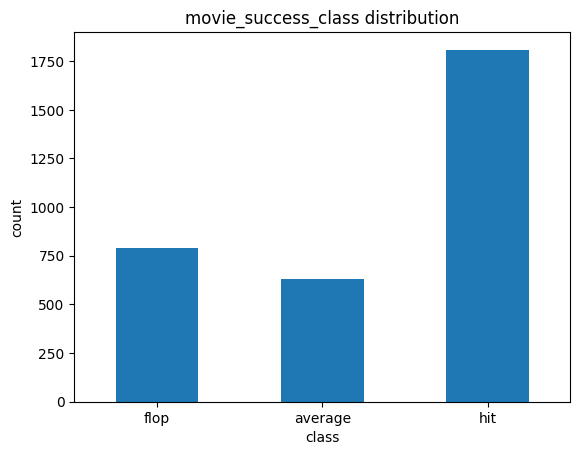

In [9]:
if movies is None:
    print("Skip: movies not loaded.")
else:
    vc = movies_valid["movie_success_class"].value_counts().sort_index()
    display(vc.to_frame("count"))
    ax = vc.plot(kind="bar", title="movie_success_class distribution", rot=0)
    ax.set_xlabel("class")
    ax.set_ylabel("count")


## 9. Modeling feature policy (pre-release vs leakage)

### Allowed pre-release features (for later pipelines)
- `budget`
- `genres` (parsed → e.g. `main_genre`, `genre_count`)
- `runtime`
- `release_month`, `release_quarter` (and `release_year` as calendar context)
- `original_language`
- `production_companies` (parsed counts / aggregations)
- `production_countries`
- `spoken_languages`

### Forbidden for *prediction* (leakage or post-release)
- `revenue` (target construction only)
- `roi` (derived from post-release revenue)
- `vote_average`, `vote_count`, `popularity` (TMDB reflects post-release audience activity)
- Any cast/crew performance metrics, box office actuals, or other post-release fields

The cleaned export **retains** revenue/roi for analysis and target verification; **drop** these columns when building `X` for modeling.


## 10. Simple derived columns for downstream modeling


In [10]:
if movies is None:
    print("Skip: movies not loaded.")
else:
    df = movies_valid.copy()

    dt = pd.to_datetime(df["release_date"], errors="coerce")
    df["release_year"] = dt.dt.year
    df["release_month"] = dt.dt.month
    df["release_quarter"] = dt.dt.quarter

    def first_name(parsed_list, key="name"):
        if not parsed_list:
            return np.nan
        first = parsed_list[0]
        if isinstance(first, dict) and key in first:
            return first[key]
        return np.nan

    df["main_genre"] = df["genres_parsed"].map(lambda x: first_name(x, "name"))
    df["genre_count"] = df["genres_parsed"].map(len)

    df["production_company_count"] = df["production_companies_parsed"].map(len)
    df["production_country_count"] = df["production_countries_parsed"].map(len)
    df["spoken_language_count"] = df["spoken_languages_parsed"].map(len)

    derived_cols = [
        "release_year",
        "release_month",
        "release_quarter",
        "main_genre",
        "genre_count",
        "production_company_count",
        "production_country_count",
        "spoken_language_count",
    ]
    display(df[derived_cols].head(10))
    display(df[derived_cols].isna().sum().to_frame("missing_after_derived"))
    movies_final = df


,release_year,release_month,release_quarter,main_genre,genre_count,production_company_count,production_country_count,spoken_language_count
0,2009,12,4,Action,4,4,2,2
1,2007,5,2,Adventure,3,3,1,1
2,2015,10,4,Action,3,3,2,5
3,2012,7,3,Action,4,4,1,1
4,2012,3,1,Action,3,1,1,1
5,2007,5,2,Fantasy,3,3,1,2
6,2010,11,4,Animation,2,2,1,1
7,2015,4,2,Action,3,3,1,1
8,2009,7,3,Adventure,3,2,2,1
9,2016,3,1,Action,3,6,1,1


,missing_after_derived
release_year,0
release_month,0
release_quarter,0
main_genre,1
genre_count,0
production_company_count,0
production_country_count,0
spoken_language_count,0


## 11. Save cleaned dataset

Intermediate artifact for EDA / feature work. List columns `*_parsed` are dropped before CSV export so the file round-trips cleanly; raw JSON strings (`genres`, etc.) remain if you need to re-parse.

**Do not** pass leakage columns to `load_dataset_split()` later.


In [11]:
if movies is None:
    print("Skip save: movies not loaded.")
else:
    parsed_cols = [c for c in movies_final.columns if c.endswith("_parsed")]
    movies_out = movies_final.drop(columns=parsed_cols, errors="ignore")
    movies_out.to_csv(OUTPUT_PATH, index=False)
    print("Wrote:", OUTPUT_PATH)
    print("shape:", movies_out.shape)


Wrote: /Users/paulbensemoun/Documents/ml_poc/new-project/data/processed/movies_cleaned_with_target.csv
shape: (3229, 30)
